## 01 — DATASET DE TREINAMENTO/VALIDAÇÃO
**Objetivo**: gerar as 10.000 vítimas do **dataset de treino/validação** com o script do professor (`gerar_dados_vitimas.py`) e calcular os valores da **tabela 1** do relatório.

**Saídas**
* `datasets/vict/10000v/data.csv`: o dataset gerado (não versionado)
* `results/dataset.json`: contagem da tri, média e dpa da idade e o ruído usado

O dataset de teste cego **não** é lido neste notebook (só no `04_teste_cego.ipynb`).

**(1) Parâmetros de geração**

O script `gerar_dados_vitimas.py` **não é alterado**. Por padrão ele grava em `datasets/vict/1300v/data.csv`; como a função `gerar_dataset_vitimas()` lê a variável global `OUTPUT_CSV` do módulo no momento da gravação, basta apontá-la para o novo caminho antes da chamada.

* `distrib_tri`: 2.500 vítimas por classe de tri (antes do ruído)
* `media_idade` e `desvio_idade`: parâmetros da normal da idade (depois truncada em [1, 90])
* `nivel_ruido`: o **ruído** (0 < ruído ≤ 0.05), que perturba as features de entrada e troca a tri por classes vizinhas
* `seed`: fixa as sementes do numpy e do `random`, para reproduzir sempre o mesmo CSV

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import gerar_dados_vitimas

# Parâmetros de geração (spec, issue #1)
DISTRIB_TRI = {0: 2500, 1: 2500, 2: 2500, 3: 2500}  # 0 verde, 1 amarelo, 2 vermelho, 3 preto
MEDIA_IDADE = 40
DESVIO_IDADE = 25
RUIDO = 0.05
SEED = 42

# Caminhos de saída
DATASET_DIR = Path("datasets/vict/10000v")
DATASET_CSV = DATASET_DIR / "data.csv"
RESULTS_JSON = Path("results/dataset.json")

DATASET_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_JSON.parent.mkdir(parents=True, exist_ok=True)

# Aponta a saída do gerador para o dataset de 10.000 vítimas
gerar_dados_vitimas.OUTPUT_CSV = DATASET_CSV

# O ruído precisa estar na faixa do enunciado
assert 0 < RUIDO <= 0.05

**(2) Geração do dataset**

A função grava o CSV, imprime a distribuição da tri após o ruído e plota o histograma da sobr.


Dataset salvo com sucesso em: datasets/vict/10000v/data.csv

Distribuição final de vítimas por classificação START (após ruído):
  0 (Verde): 2448 (24.5%)
  1 (Amarelo): 2567 (25.7%)
  2 (Vermelho): 2561 (25.6%)
  3 (Preto): 2424 (24.2%)
total de vítimas: 10000


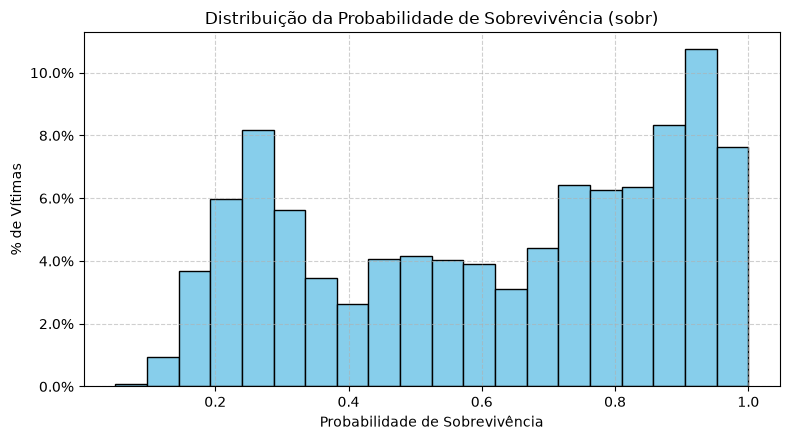

In [2]:
df_gerado = gerar_dados_vitimas.gerar_dataset_vitimas(
    distrib_tri=DISTRIB_TRI,
    media_idade=MEDIA_IDADE,
    desvio_idade=DESVIO_IDADE,
    nivel_ruido=RUIDO,
    seed=SEED,
)

**(3) Leitura e verificação do CSV gerado**

A tabela 1 usa os valores **medidos no CSV gravado**, por isso o arquivo é relido do disco. Verificamos o número de vítimas e as 14 colunas na ordem da tabela 1 do enunciado.

In [3]:
df = pd.read_csv(DATASET_CSV)

# 14 colunas na ordem do enunciado: features de entrada (1 a 10), gcs, avpu, tri e sobr
COLUNAS = ['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim',
           'gcs', 'avpu', 'tri', 'sobr']

assert len(df) == 10000, f"esperado 10000 vítimas, obtido {len(df)}"
assert list(df.columns) == COLUNAS, f"colunas fora da ordem: {list(df.columns)}"

print(f"Arquivo.....:\t{DATASET_CSV}")
print(f"Vítimas.....:\t{len(df):>6}")
print(f"Colunas.....:\t{len(df.columns):>6}")
df.head()

Arquivo.....:	datasets/vict/10000v/data.csv
Vítimas.....:	 10000
Colunas.....:	    14


,idade,fc,fr,pas,spo2,temp,pr,sg,fx,queim,gcs,avpu,tri,sobr
0,52,95,23,82,92,35.0,1,2,0,0,12,1,1,0.67
1,36,121,7,62,85,31.8,0,1,0,3,9,2,2,0.47
2,56,119,6,182,83,39.2,1,1,0,2,10,2,2,0.56
3,78,72,13,132,95,36.3,1,0,0,0,15,1,1,0.95
4,34,114,19,92,91,38.0,1,2,1,1,11,2,1,0.66


**(4) Valores da tabela 1**

* Contagem da coluna **tri** (após o ruído, por isso não é exatamente 2.500 por classe)
* Média e **dpa** (desvio padrão amostral, `ddof=1`) da coluna idade
* O ruído usado na geração

In [4]:
CORES_TRI = {0: 'verde', 1: 'amarelo', 2: 'vermelho', 3: 'preto'}

contagem = df['tri'].value_counts()
contagem_tri = {cor: int(contagem.get(k, 0)) for k, cor in CORES_TRI.items()}
assert sum(contagem_tri.values()) == len(df)

media_idade = float(df['idade'].mean())
dpa_idade = float(df['idade'].std(ddof=1))  # ddof=1: desvio padrão amostral

for cor, n in contagem_tri.items():
    print(f"Vítimas tri={cor:<9}\t{n:>6}")
print(f"Idade das vítimas (média)\t{media_idade:>9.4f}")
print(f"Desvio padrão amostral idade\t{dpa_idade:>9.4f}")
print(f"Ruído\t\t\t\t{RUIDO:>9.2f}")

Vítimas tri=verde    	  2448
Vítimas tri=amarelo  	  2567
Vítimas tri=vermelho 	  2561
Vítimas tri=preto    	  2424
Idade das vítimas (média)	  39.9198
Desvio padrão amostral idade	  23.2016
Ruído				     0.05


**(5) Gravação em `results/dataset.json`**

Este JSON é lido pelo `04_teste_cego.ipynb` para montar a tabela 1 do relatório.

In [5]:
resultado = {
    'n_vitimas': int(len(df)),
    'tri': contagem_tri,
    'idade': {'media': media_idade, 'dpa': dpa_idade},
    'ruido': RUIDO,
    'parametros_gerador': {
        'distrib_tri': {str(k): v for k, v in DISTRIB_TRI.items()},
        'media_idade': MEDIA_IDADE,
        'desvio_idade': DESVIO_IDADE,
        'nivel_ruido': RUIDO,
        'seed': SEED,
    },
}

assert 0 < resultado['ruido'] <= 0.05

with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(resultado, f, indent=2, ensure_ascii=False)
    f.write('\n')

print(RESULTS_JSON.read_text(encoding='utf-8'))

{
  "n_vitimas": 10000,
  "tri": {
    "verde": 2448,
    "amarelo": 2567,
    "vermelho": 2561,
    "preto": 2424
  },
  "idade": {
    "media": 39.9198,
    "dpa": 23.201564585603318
  },
  "ruido": 0.05,
  "parametros_gerador": {
    "distrib_tri": {
      "0": 2500,
      "1": 2500,
      "2": 2500,
      "3": 2500
    },
    "media_idade": 40,
    "desvio_idade": 25,
    "nivel_ruido": 0.05,
    "seed": 42
  }
}

